El presente experimento se centra en la evaluación de modelos de anotación celular sobre el conjunto de datos **Mouse from MCA**, empleando para ello un pipeline de procesamiento desarrollado con **Scanpy**. A diferencia del procesado proporcionado por DANCE, este enfoque permite un mayor control sobre las distintas etapas del tratamiento de los datos.


# **Configuración del entorno**

La configuración del entorno se integra directamente en el notebook. Con el objetivo de mejorar la trazabilidad, se opta por **clonar el repositorio oficial de DANCE e instalarlo en modo editable**. Asimismo, se fijan versiones concretas de las librerías principales.

## **Configuración inicial: Python**
Se ha utilizando una versión específica del entorno de ejecución para garantizar compatibilidad con las dependencias del framework DANCE.

Se ha seleccionado la versión de runtime **2025.07**, que utiliza:

- **Python 3.11.13**

Esta elección es necesaria debido a que DANCE y varias de sus dependencias no son compatibles con versiones más recientes de Python (por ejemplo, Python 3.12).

In [2]:
# Comprobación de versión de Python
import sys
print("Python version:", sys.version)

assert sys.version_info[:2] == (3, 11), "El entorno debe usar Python 3.11"

Python version: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]


## **Instalación de libreías y dependencias**

En primer lugar se procede a la **limpieza del entorno**, eliminando paquetes potencialmente incompatibles.

Posteriormente, se lleva a cabo una **instalación explícita** de las librerías necesarias, fijando versiones concretas alineadas con los requisitos del ecosistema de **DANCE**.
Las principales versiones utilizadas en este experimento son:

- **NumPy**: 1.26.4  
- **SciPy**: 1.12.0  
- **pandas**: 2.2.2  
- **Numba**: 0.60.0  
- **llvmlite**: 0.43.0  
- **Scanpy**: 1.10.1  
- **AnnData**: 0.10.8  
- **scikit-learn**: 1.5.1  
- **PyTorch**: 2.2.2  
- **torchvision**: 0.17.2  
- **DGL**: 1.1.3  




### **Resolución de conflictos de dependencias**

Durante la configuración del entorno se identificaron diversas incompatibilidades entre versiones de librerías, principalmente derivadas de la evolución del ecosistema científico de Python y de dependencias no actualizadas en el framework **DANCE**.

El conflicto más relevante se produjo con **scikit-learn**, manifestándose en el error:
- `ImportError: cannot import name 'issparse' from sklearn.utils`

Este problema se debe a la eliminación o reubicación de funciones en versiones recientes de la librería. Para mitigar este conflicto, se fijó una versión compatible:
- **scikit-learn == 1.5.1**


In [1]:
!pip uninstall -y torch torchvision torchaudio torchtext
!pip uninstall -y scanpy anndata scikit-learn scipy numpy numba llvmlite
!pip uninstall -y pydance dance
!pip uninstall -y igraph leidenalg louvain
!pip install igraph leidenalg


%pip install -q --upgrade pip setuptools wheel
%pip install -q "numpy==1.26.4"
%pip install -q "scipy==1.12.0"
%pip install -q "pandas==2.2.2"
%pip install -q "numba==0.60.0" "llvmlite==0.43.0"
%pip install -q "anndata==0.10.8" "scanpy==1.10.1"
%pip install -q "scikit-learn==1.5.1"
%pip install -q "statsmodels>=0.14" "h5py==3.11.0" "KDEpy==1.1.9"



%pip install -q torch==2.2.2 torchvision==0.17.2 --index-url https://download.pytorch.org/whl/cpu
%pip install -q dgl==1.1.3 -f https://data.dgl.ai/wheels/repo.html

# Dependencias adicionales necesarias para DANCE
%pip install -q mudata==0.2.3
%pip install -q omegaconf openpyxl requests tables tifffile tqdm scikit-misc
%pip install -q omegaconf openpyxl requests tables tifffile tqdm scikit-misc Deprecated



Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
Found existing installation: torchvision 0.21.0+cu124
Uninstalling torchvision-0.21.0+cu124:
  Successfully uninstalled torchvision-0.21.0+cu124
Found existing installation: torchaudio 2.6.0+cu124
Uninstalling torchaudio-2.6.0+cu124:
  Successfully uninstalled torchaudio-2.6.0+cu124
Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
Found existing installation: scipy 1.15.3
Uninstalling scipy-1.15.3:
  Successfully uninstalled scipy-1.15.3
Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: numba 0.60.0
Uninstalling numba-0.60.0:
  Successfully uninstalled numba-0.60.0
Found existing installation: llvmlite 0.43.0
Uninstalling llvmlite-0.43.0:
  Successfully uninstalled llvmlite-0.43.0
   ━━━━━━━━━━━━━━━━━━━━

 Reinicio del entorno

In [1]:
#Comprobación
import numpy as np
import scipy
import pandas as pd
import sklearn
import scanpy as sc
import anndata
import h5py

print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("Pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("Scanpy:", sc.__version__)
print("AnnData:", anndata.__version__)
print("h5py:", h5py.__version__)

NumPy: 1.26.4
SciPy: 1.12.0
Pandas: 2.2.2
scikit-learn: 1.5.1
Scanpy: 1.10.1
AnnData: 0.10.8
h5py: 3.11.0


## **Clonación del repositorio DANCE: última versión v2**

Para este experimento se utiliza directamente el repositorio oficial de **DANCE**, en lugar de la versión distribuida a través de PyPI.

El repositorio se clona directamente desde GitHub dentro del entorno de ejecución..

In [2]:
# Clonación del repositorio

!rm -rf /content/dance
!git clone https://github.com/OmicsML/dance.git /content/dance

Cloning into '/content/dance'...
remote: Enumerating objects: 13028, done.
remote: Counting objects: 100% (2193/2193), done.
remote: Compressing objects: 100% (144/144), done.
remote: Total 13028 (delta 2120), reused 2049 (delta 2049), pack-reused 10835 (from 1)
Receiving objects: 100% (13028/13028), 19.70 MiB | 10.45 MiB/s, done.
Resolving deltas: 100% (8759/8759), done.


### Aplicación de parches de compatibilidad

A pesar de fijar versiones compatibles, el repositorio de **DANCE** presenta incompatibilidades con versiones actuales de algunas librerías. En particular, se detecta el uso de la importación `from sklearn.utils import issparse`, que ya no está disponible en versiones recientes de *scikit-learn*.

Para resolver este problema, se aplica un parche global sobre el código fuente del repositorio, reemplazando dicha importación por `from scipy.sparse import issparse`.

Esta modificación permite mantener la funcionalidad original del código asegurando la compatibilidad con el entorno actual, sin necesidad de degradar versiones de dependencias. La transformación aplicada es:

`from sklearn.utils import issparse` → `from scipy.sparse import issparse`

In [3]:
# Parche global de issparse

from pathlib import Path

repo_root = Path("/content/dance")
target = "from sklearn.utils import issparse"
replacement = "from scipy.sparse import issparse"

patched_files = []

for py_file in repo_root.rglob("*.py"):
    text = py_file.read_text(encoding="utf-8")
    if target in text:
        text = text.replace(target, replacement)
        py_file.write_text(text, encoding="utf-8")
        patched_files.append(str(py_file))

print("Archivos parcheados:", len(patched_files))

Archivos parcheados: 4


### Configuración del path y carga del repositorio

Para garantizar que Python utiliza la versión del repositorio clonada localmente, se modifica el *path* de ejecución.

Se inserta la ruta del repositorio en la primera posición de `sys.path`, priorizando su uso durante la importación de módulos. Adicionalmente, se eliminan posibles módulos previamente cargados en memoria, evitando inconsistencias derivadas del sistema de caché de Python.



In [4]:
import sys

# Añadir repo al path
sys.path.insert(0, "/content/dance")

# Limpiar módulos cargados previamente
for mod in list(sys.modules):
    if mod == "dance" or mod.startswith("dance."):
        del sys.modules[mod]

print("Path configurado correctamente.")

Path configurado correctamente.


## **Verificación del entorno**


In [5]:
# Verificación final

from dance.datasets.singlemodality import CellTypeAnnotationDataset
from dance.modules.single_modality.cell_type_annotation.actinn import ACTINN
from dance.modules.single_modality.cell_type_annotation.svm import SVM
from dance.modules.single_modality.cell_type_annotation.celltypist import Celltypist
from dance.modules.single_modality.cell_type_annotation.singlecellnet import SingleCellNet
from dance.modules.single_modality.cell_type_annotation.scdeepsort import ScDeepSort
from dance.utils import set_seed


print("CellTypeAnnotationDataset OK")
print("ACTINN OK")
print("SVM OK")
print("Celltypist OK")
print("SingleCellNet OK")
print("ScDeepSort OK")
print("set_seed OK")

DGL backend not selected or invalid.  Assuming PyTorch for now.


Setting the default backend to "pytorch". You can change it in the ~/.dgl/config.json file or export the DGLBACKEND environment variable.  Valid options are: pytorch, mxnet, tensorflow (all lowercase)


/content/dance/dance/utils/matrix.py:178: NumbaExperimentalFeatureWarning: First-class function type feature is experimental
  for j in numba.prange(n):


CellTypeAnnotationDataset OK
ACTINN OK
SVM OK
Celltypist OK
SingleCellNet OK
ScDeepSort OK
set_seed OK


# **1. Carga e inspección inicial de los datos**

Se realiza la carga del dataset **Mouse from MCA** y una primera inspección de su estructura interna. El objetivo es verificar la correcta importación de los datos, identificar la organización del objeto `AnnData` y comprobar que contiene la información necesaria para el análisis exploratorio y el posterior pipeline de preprocesado con Scanpy.

## **1.1. Carga del dataset**

El dataset se obtiene mediante la librería DANCE.
Se define explícitamente la configuración del dataset, especificando la especie, el tejido y los subconjuntos de datos utilizados en el experimento. En particular, se selecciona el tejido cerebral de ratón (*mouse brain*), definiendo dos subconjuntos de entrenamiento y uno de prueba:

- entrenamiento: 753 y 3285
- prueba: 2695



In [6]:
from dance.datasets.singlemodality import CellTypeAnnotationDataset

# CONSTRUCCIÓN DEL DATASET

dataset = CellTypeAnnotationDataset(
    species="mouse",
    tissue="Brain",
    train_dataset=[753, 3285],
    test_dataset=[2695],
    val_size=0.0
)

# SIN PREPROCESADO
data = dataset.load_data(transform=None, cache=False)

print("Dataset construido correctamente.")
print("Tipo de objeto:", type(dataset))


[INFO][2026-05-19 17:12:24,548][dance][is_complete] ./test/mouse/mouse_Brain2695_celltype.csv
[INFO][2026-05-19 17:12:24,550][dance][is_complete] file mouse_Brain2695_celltype.csv doesn't exist
[INFO][2026-05-19 17:12:24,552][dance][is_complete] ./test/mouse/mouse_Brain2695_celltype.csv
[INFO][2026-05-19 17:12:24,554][dance][is_complete] file mouse_Brain2695_celltype.csv doesn't exist
[INFO][2026-05-19 17:12:25,771][dance][download_file] Downloading: ./test/mouse/mouse_Brain2695_celltype.csv Bytes: 95,883
100%|██████████| 93.6k/93.6k [00:00<00:00, 15.5MB/s]
[INFO][2026-05-19 17:12:27,232][dance][download_file] Downloading: ./test/mouse/mouse_Brain2695_data.csv Bytes: 269,468,417
100%|██████████| 257M/257M [00:08<00:00, 30.1MB/s]
[INFO][2026-05-19 17:12:38,052][dance][download_file] Downloading: ./train/mouse/mouse_Brain3285_celltype.csv Bytes: 146,995
100%|██████████| 144k/144k [00:00<00:00, 224kB/s]
[INFO][2026-05-19 17:12:40,440][dance][download_file] Downloading: ./train/mouse/mouse

Dataset construido correctamente.
Tipo de objeto: <class 'dance.datasets.singlemodality.CellTypeAnnotationDataset'>


## **1.2. Anndata**

El objeto de datos de DANCE se basa en gran medida en AnnData, un objeto de datos muy utilizado para representar, almacenar y manipular grandes matrices anotadas.

AnnData forma parte del ecosistema de scVerse, lo que proporciona ventajas adicionales y facilita el manejo de datos de célula única utilizando, por ejemplo, Scanpy.

In [7]:
#Extraer AnnData
adata = data.data
adata

AnnData object with n_obs × n_vars = 6733 × 19856
    uns: 'dance_config'
    obsm: 'cell_type'

### **1.2.1. Exploración**

**Números de células y genes**

La primera comprobación consiste en examinar la dimensionalidad global del objeto `AnnData`, identificando el número de células y el número de genes contenidos en la matriz de expresión.

En este tipo de estructuras, las filas representan células individuales y las columnas representan genes.

In [8]:
# Dimensiones del dataset
print("Forma del dataset (células, genes):", adata.shape)

print("Número de células:", adata.n_obs)
print("Número de genes:", adata.n_vars)

# Tipo de matriz
print("Tipo de adata.X:", type(adata.X))

# Comprobar si es dispersa
from scipy import sparse
if sparse.issparse(adata.X):
    print("La matriz es dispersa")
else:
    print("La matriz es densa")

Forma del dataset (células, genes): (6733, 19856)
Número de células: 6733
Número de genes: 19856
Tipo de adata.X: <class 'numpy.ndarray'>
La matriz es densa


**Estructura interna**

Se inspeccionan los distintos compartimentos del objeto `AnnData` con el fin de identificar la información disponible en cada uno de ellos.

En particular:

- `adata.obs` contiene metadatos asociados a las células.
- `adata.var` contiene metadatos asociados a los genes.
- `adata.obsm` almacena representaciones auxiliares asociadas a las observaciones.
- `adata.uns` contiene información no estructurada.


In [9]:
print("Claves en adata.obs:")
print(list(adata.obs.columns))

print("\nClaves en adata.var:")
print(list(adata.var.columns))

print("\nClaves en adata.obsm:")
print(list(adata.obsm.keys()))

print("\nClaves en adata.uns:")
print(list(adata.uns.keys()))

Claves en adata.obs:
[]

Claves en adata.var:
[]

Claves en adata.obsm:
['cell_type']

Claves en adata.uns:
['dance_config']


La ausencia de columnas en `adata.obs` y `adata.var` indica que el conjunto de datos no incorpora, en esta fase de carga, anotaciones complementarias de células o genes. En consecuencia, toda la información esencial para el análisis inicial debe derivarse directamente de la matriz de expresión `adata.X` y de las estructuras auxiliares asociadas.

En particular, la presencia de `adata.obsm['cell_type']` confirma que las etiquetas celulares están disponibles, aunque en un formato matricial que requiere transformación.

**Identificación de las etiquetas celulares**

La anotación celular del conjunto de datos se encuentra almacenada en `adata.obsm['cell_type']`. Esta estructura presenta dimensión `(6733, 11)`, lo que indica que para cada una de las 6733 células se dispone de una codificación asociada a 11 tipos celulares distintos.


In [10]:
import pandas as pd

adata.obsm["cell_type"]



,Astrocyte,Astroglial cell,Granulocyte,Hypothalamic ependymal cell,Macrophage,Microglia,Myelinating oligodendrocyte,Neuron,Oligodendrocyte precursor cell,Pan-GABAergic,Schwann cell
mouse_Brain753_C_1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
mouse_Brain753_C_2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
mouse_Brain753_C_3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
mouse_Brain753_C_4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
mouse_Brain753_C_5,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
mouse_Brain2695_C_2691,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mouse_Brain2695_C_2692,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mouse_Brain2695_C_2693,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mouse_Brain2695_C_2694,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### **1.2.2. Conversión de la anotación `cell_type` a formato categórico**

La inspección de las primeras filas permite comprobar que dicha matriz sigue un esquema de codificación one-hot, en el que cada célula queda asociada a una única clase activa.
Se transforma la matriz `cell_type` en una etiqueta categórica única por célula, almacenada en `adata.obs['cell_type']`.

In [11]:
import numpy as np
import pandas as pd

labels = adata.obsm["cell_type"]

# Decodificación de etiquetas one-hot
if len(labels.shape) > 1 and labels.shape[1] > 1:
    labels_decoded = np.argmax(labels, axis=1)
else:
    labels_decoded = np.asarray(labels).ravel()

# Guardar en obs
adata.obs["cell_type"] = labels_decoded

# Convertir a categórica
adata.obs["cell_type"] = pd.Categorical(adata.obs["cell_type"])

print("Primeras etiquetas:")
print(adata.obs["cell_type"].head())

print("\nCategorías:")
print(adata.obs["cell_type"].cat.categories)

print("\nNúmero de clases:")
print(adata.obs["cell_type"].nunique())

Primeras etiquetas:
mouse_Brain753_C_1    5
mouse_Brain753_C_2    5
mouse_Brain753_C_3    5
mouse_Brain753_C_4    5
mouse_Brain753_C_5    5
Name: cell_type, dtype: category
Categories (11, int64): [0, 1, 2, 3, ..., 7, 8, 9, 10]

Categorías:
Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype='int64')

Número de clases:
11


In [12]:
adata.obs

,cell_type
mouse_Brain753_C_1,5
mouse_Brain753_C_2,5
mouse_Brain753_C_3,5
mouse_Brain753_C_4,5
mouse_Brain753_C_5,5
...,...
mouse_Brain2695_C_2691,3
mouse_Brain2695_C_2692,3
mouse_Brain2695_C_2693,3
mouse_Brain2695_C_2694,3


### **1.2.3. Distribución de clases celulares**

Una vez reconstruida la anotación celular en formato categórico, se analiza la distribución de clases presente en el dataset. Este análisis puede identificar posibles desbalances entre tipos celulares.


In [13]:
print(adata.obs["cell_type"].value_counts())

cell_type
6     3970
7     1676
5      436
0      328
4      124
8       72
1       30
3       29
2       26
9       26
10      16
Name: count, dtype: int64


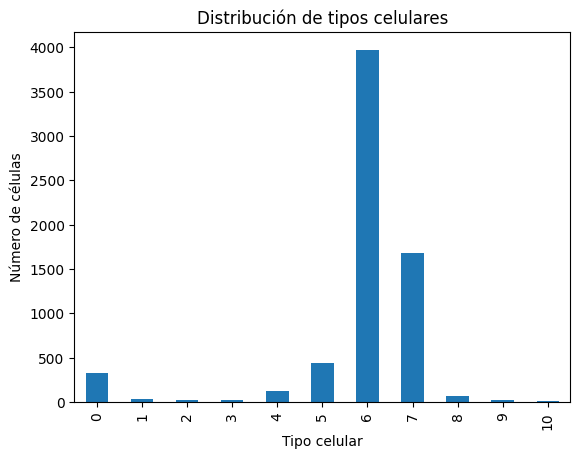

In [14]:
import matplotlib.pyplot as plt
adata.obs["cell_type"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribución de tipos celulares")
plt.xlabel("Tipo celular")
plt.ylabel("Número de células")
plt.show()

**Identificadores de células y genes**

Se inspeccionan los identificadores de células y genes.

In [15]:
print("Primeras células:")
print(adata.obs_names[:5])

print("\nPrimeros genes:")
print(adata.var_names[:20])

Primeras células:
Index(['mouse_Brain753_C_1', 'mouse_Brain753_C_2', 'mouse_Brain753_C_3',
       'mouse_Brain753_C_4', 'mouse_Brain753_C_5'],
      dtype='object')

Primeros genes:
Index(['0610005C13Rik', '0610009B22Rik', '0610009E02Rik', '0610009L18Rik',
       '0610010F05Rik', '0610010K14Rik', '0610012G03Rik', '0610025J13Rik',
       '0610030E20Rik', '0610039K10Rik', '0610040B10Rik', '0610040F04Rik',
       '0610040J01Rik', '1010001B22Rik', '1110002E22Rik', '1110002L01Rik',
       '1110002O04Rik', '1110003F10Rik', '1110004F10Rik', '1110006O24Rik'],
      dtype='object')


**Análisis de la matriz de expresión génica**

La matriz `adata.X` contiene la expresión génica (células × genes).

In [16]:
counts_RNA = adata.X

print("Dimensión:", counts_RNA.shape)

if sparse.issparse(counts_RNA):
    print(counts_RNA[:5, :10].toarray())
else:
    print(counts_RNA[:5, :10])

Dimensión: (6733, 19856)
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


# **2. Procesamiento y clustering**

Para llevar a cabo esta sección, se sigue un tutorial de Scanpy: https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html#manual-cell-type-annotation

Se sustituye la fase de procesamiento de DANCE por un pipeline basado en Scanpy.

## **2.1. Inspección inicial**



In [18]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from scipy import sparse

# Hacemos una copia para no modificar el objeto original cargado
adata_proc = adata.copy()

print("ANTES DEL PROCESADO:")
print(f"Número de células: {adata_proc.n_obs}")
print(f"Número de genes: {adata_proc.n_vars}")
print(f"Shape: {adata_proc.shape}")

# Comprobar si la matriz es dispersa o densa
if sparse.issparse(adata_proc.X):
    print("Tipo de matriz: dispersa")
    X_array = adata_proc.X.toarray()
else:
    print("Tipo de matriz: densa")
    X_array = adata_proc.X

# Estadísticas básicas
print(f"Mínimo global: {X_array.min()}")
print(f"Máximo global: {X_array.max()}")
print(f"Media global: {X_array.mean():.4f}")

# Suma total de expresión por célula
cell_sums_before = X_array.sum(axis=1)

print("\nSuma total de expresión por célula (primeras 10):")
print(cell_sums_before[:10])

ANTES DEL PROCESADO:
Número de células: 6733
Número de genes: 19856
Shape: (6733, 19856)
Tipo de matriz: densa
Mínimo global: 0.0
Máximo global: 8.209492683410645
Media global: 0.1231

Suma total de expresión por célula (primeras 10):
[1336.9628 1388.6519 1245.6354 1232.6874 1519.3655 1279.0011 1314.1104
 1247.7872 1413.8015 1626.5261]


## **2.2. Control de calidad (Quality Control)**

En esta fase se calculan métricas estándar de calidad mediante la función `calculate_qc_metrics` de Scanpy:

- el número de genes detectados por célula (`n_genes_by_counts`),
- el número total de cuentas por célula (`total_counts`),
- y el porcentaje de expresión correspondiente a genes mitocondriales (`pct_counts_mt`).

Para ello, se intentó identificar estos grupos a partir de los nombres génicos contenidos en el objeto `AnnData`. En el caso de los genes ribosomales y de hemoglobina, la detección pudo realizarse de forma directa mediante prefijos estándar. Sin embargo, en el caso de los genes mitocondriales no fue posible recuperar una anotación representativa utilizando la nomenclatura habitual, por lo que la métrica `pct_counts_mt` no resultó informativa en este conjunto de datos.



In [19]:
# Identificación de tipos de genes

# dataset de ratón → "Mt-" (no "MT-")
adata_proc.var["mt"] = adata_proc.var_names.str.startswith("Mt-") # en este dataset apenas informativo
# Genes ribosomales
adata_proc.var["ribo"] = adata_proc.var_names.str.startswith(("Rps", "Rpl"))
# Genes de hemoglobina
adata_proc.var["hb"] = adata_proc.var_names.str.contains("^Hb")

print("Genes mitocondriales detectados:", adata_proc.var["mt"].sum())
print("Genes ribosomales detectados:", adata_proc.var["ribo"].sum())
print("Genes de hemoglobina detectados:", adata_proc.var["hb"].sum())

# Cálculo de métricas QC
sc.pp.calculate_qc_metrics(
    adata_proc,
    qc_vars=["mt", "ribo", "hb"],
    inplace=True,
    log1p=False   # ya parece log-transformado
)

print("QC metrics calculadas correctamente")

Genes mitocondriales detectados: 0
Genes ribosomales detectados: 272
Genes de hemoglobina detectados: 11
QC metrics calculadas correctamente


### **Visualización de métricas de calidad**

Se utilizan diagramas de violín para representar:

- el número de genes detectados por célula,
- el número total de cuentas,
- y el porcentaje de expresión ribo y hemoglobina.



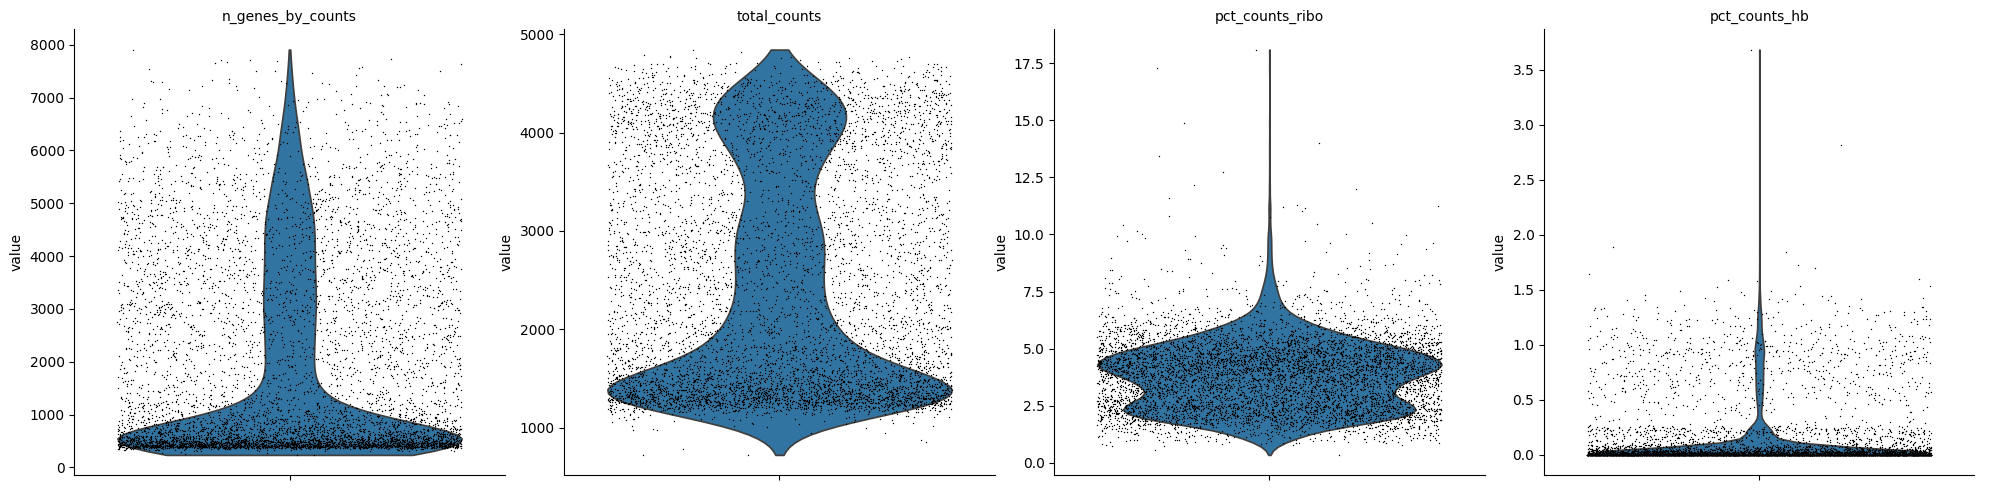

In [20]:
sc.pl.violin(
    adata_proc,
    ["n_genes_by_counts", "total_counts", "pct_counts_ribo", "pct_counts_hb"],
    jitter=0.4,
    multi_panel=True
)

### **Análisis conjunto de métricas de calidad**

Se emplea un diagrama de dispersión que relaciona el número total de cuentas con el número de genes detectados por célula, coloreado según el porcentaje de expresión de genes ribonucleicos (`pct_counts_ribo`).



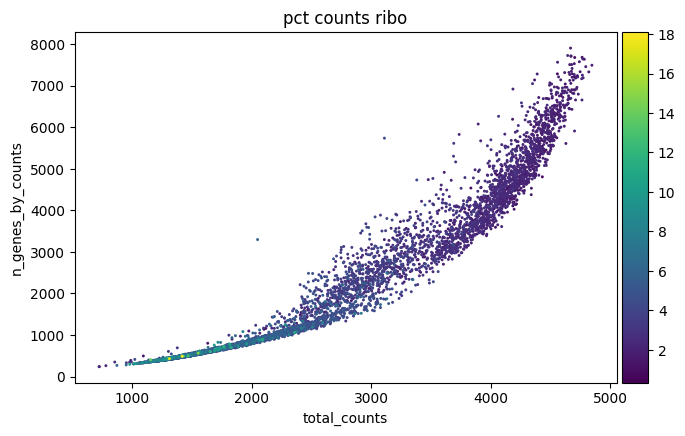

In [21]:
sc.pl.scatter(
    adata_proc,
    x="total_counts",
    y="n_genes_by_counts",
    color="pct_counts_ribo"
)

### **Filtrado inicial de células y genes**

Se eliminan:

- las células con menos de 100 genes detectados, ya que suelen corresponder a células de baja calidad o vacías,
- y los genes que se expresan en menos de 3 células, por su escasa relevancia informativa.


In [22]:
# Filtrado de células
sc.pp.filter_cells(adata_proc, min_genes=100)

# Filtrado de genes
sc.pp.filter_genes(adata_proc, min_cells=3)

print("Filtrado inicial completado")
print("Nuevo shape:", adata_proc.shape)

Filtrado inicial completado
Nuevo shape: (6733, 17389)


### **Detección de dobletes**


Para su identificación, se emplea el algoritmo **Scrublet**, implementado en Scanpy, que predice la probabilidad de que cada observación corresponda a un doblete mediante la comparación con dobletes simulados.

El algoritmo añade dos variables al objeto:

- `doublet_score`: puntuación continua asociada a la probabilidad de ser doblete,
- `predicted_doublet`: clasificación binaria de cada célula.

In [23]:
# Detección de dobletes
sc.pp.scrublet(adata_proc)

print("Detección de dobletes completada")

Detección de dobletes completada


## **2.3. Normalización de los datos**

Dado que los datos utilizados proceden directamente de la clase CellTypeAnnotationDataset de DANCE, y el propio framework indica que dichos datasets se consideran previamente normalizados, no se aplicó una etapa adicional de normalización dentro del pipeline desarrollado en Scanpy.



In [24]:
X_array = adata_proc.X
np.max(X_array)

8.209493

In [25]:
# Guardamos una copia de la matriz actual
#adata_proc.layers["original"] = adata_proc.X.copy()

# Normalización por profundidad de secuenciación
#sc.pp.normalize_total(adata_proc, target_sum=1e4)

# Transformación logarítmica
#sc.pp.log1p(adata_proc)

print("Normalización y transformación log1p completadas")
print("Nuevo máximo:", adata_proc.X.max())

Normalización y transformación log1p completadas
Nuevo máximo: 8.209493


## **2.4. Selección de genes altamente variables (HVGs)**

Se identifican los **genes altamente variables** (*Highly Variable Genes*, HVGs), es decir, aquellos cuya variabilidad entre células es especialmente elevada una vez controlado el nivel medio de expresión.

En este trabajo se emplea la función `highly_variable_genes` de Scanpy sobre la matriz ya normalizada y transformada logarítmicamente, utilizando el criterio estándar inspirado en Seurat.

Siguiendo una práctica habitual en análisis de transcriptómica de célula única, se seleccionan los **2.000 genes más variables**.

In [26]:
sc.pp.highly_variable_genes(
    adata_proc,
    n_top_genes=2000,
    flavor="seurat"
)

print("Selección de genes altamente variables completada")
print("Número de HVGs seleccionados:", adata_proc.var["highly_variable"].sum())

Selección de genes altamente variables completada
Número de HVGs seleccionados: 2000


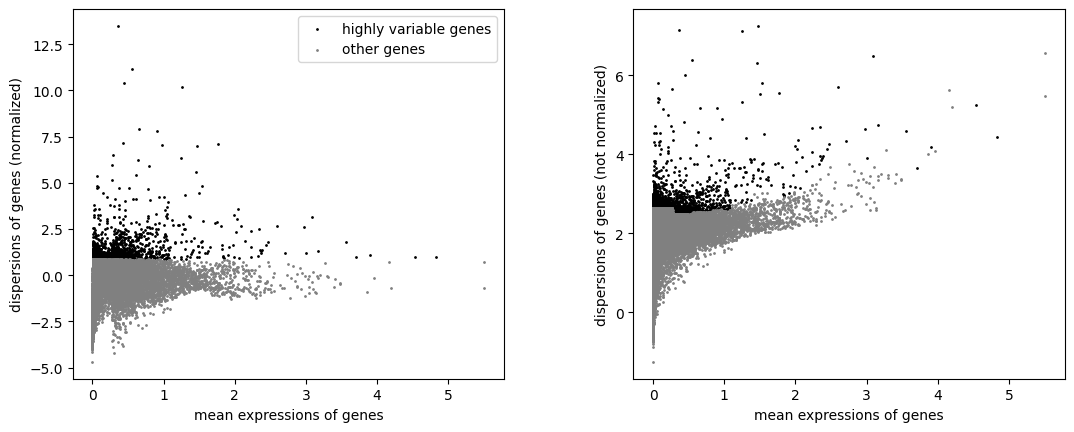

In [27]:
sc.pl.highly_variable_genes(adata_proc)

In [28]:
adata_hvg = adata_proc[:, adata_proc.var["highly_variable"]].copy()

print("Dimensión original:", adata_proc.shape)
print("Dimensión tras seleccionar HVGs:", adata_hvg.shape)

Dimensión original: (6733, 17389)
Dimensión tras seleccionar HVGs: (6733, 2000)


## **2.5. Reducción de dimensionalidad mediante PCA**

Se emplea el **Análisis de Componentes Principales** (*Principal Component Analysis*, PCA).


In [29]:
sc.tl.pca(adata_hvg)

print("PCA calculada correctamente")

PCA calculada correctamente


### **Análisis de la varianza explicada**


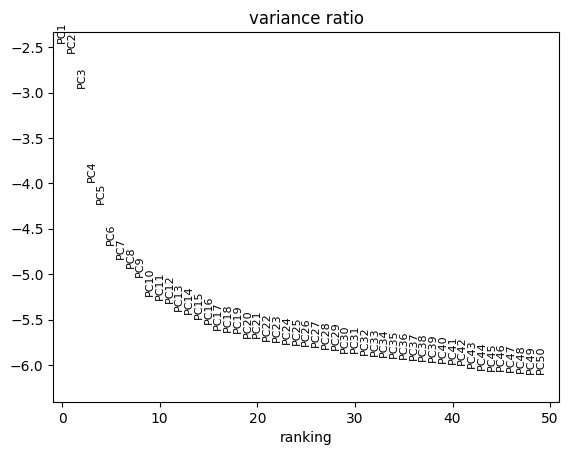

In [30]:
sc.pl.pca_variance_ratio(adata_hvg, n_pcs=50, log=True)

### **Exploración de posibles fuentes de variación técnica**
Se inspecciona la distribución de determinadas métricas de calidad en el espacio definido por los primeros componentes principales.


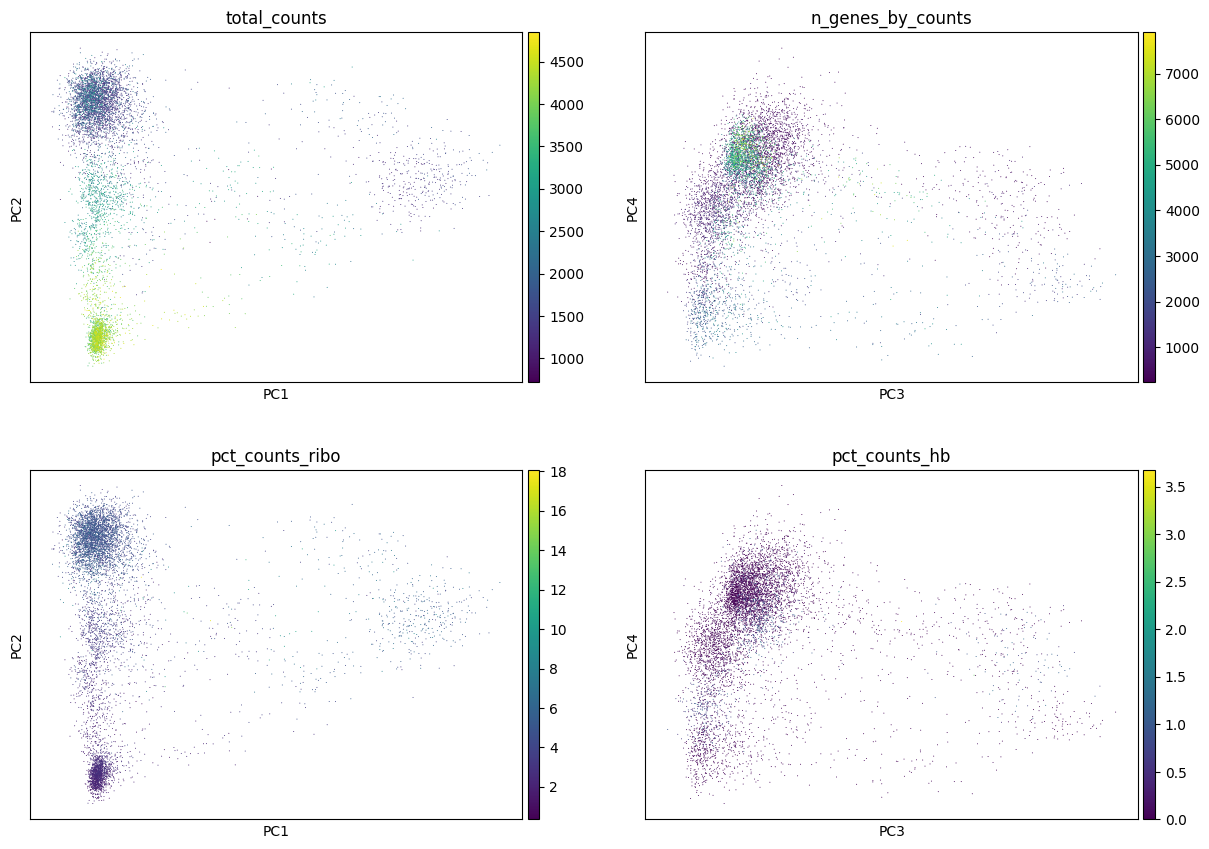

In [31]:
sc.pl.pca(
    adata_hvg,
    color=["total_counts", "n_genes_by_counts", "pct_counts_ribo", "pct_counts_hb"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2
)

## **2.6. Construcción del grafo de vecinos y visualización mediante UMAP**

Se construye un grafo de vecindad entre células a partir de dicha representación reducida. Este grafo permite modelar relaciones de similitud local entre observaciones.

En Scanpy, este paso se realiza mediante la función `neighbors`, que calcula, para cada célula, sus vecinos más próximos en el espacio definido por la PCA. L

A continuación, se aplica **UMAP** (*Uniform Manifold Approximation and Projection*), una técnica de reducción de dimensionalidad no lineal ampliamente utilizada en análisis de célula única.

In [32]:
sc.pp.neighbors(adata_hvg, n_pcs=30)

print("Grafo de vecinos calculado correctamente")

Grafo de vecinos calculado correctamente


In [33]:
sc.tl.umap(adata_hvg)

print("UMAP calculado correctamente")

UMAP calculado correctamente


### **Visualización inicial de la proyección UMAP**


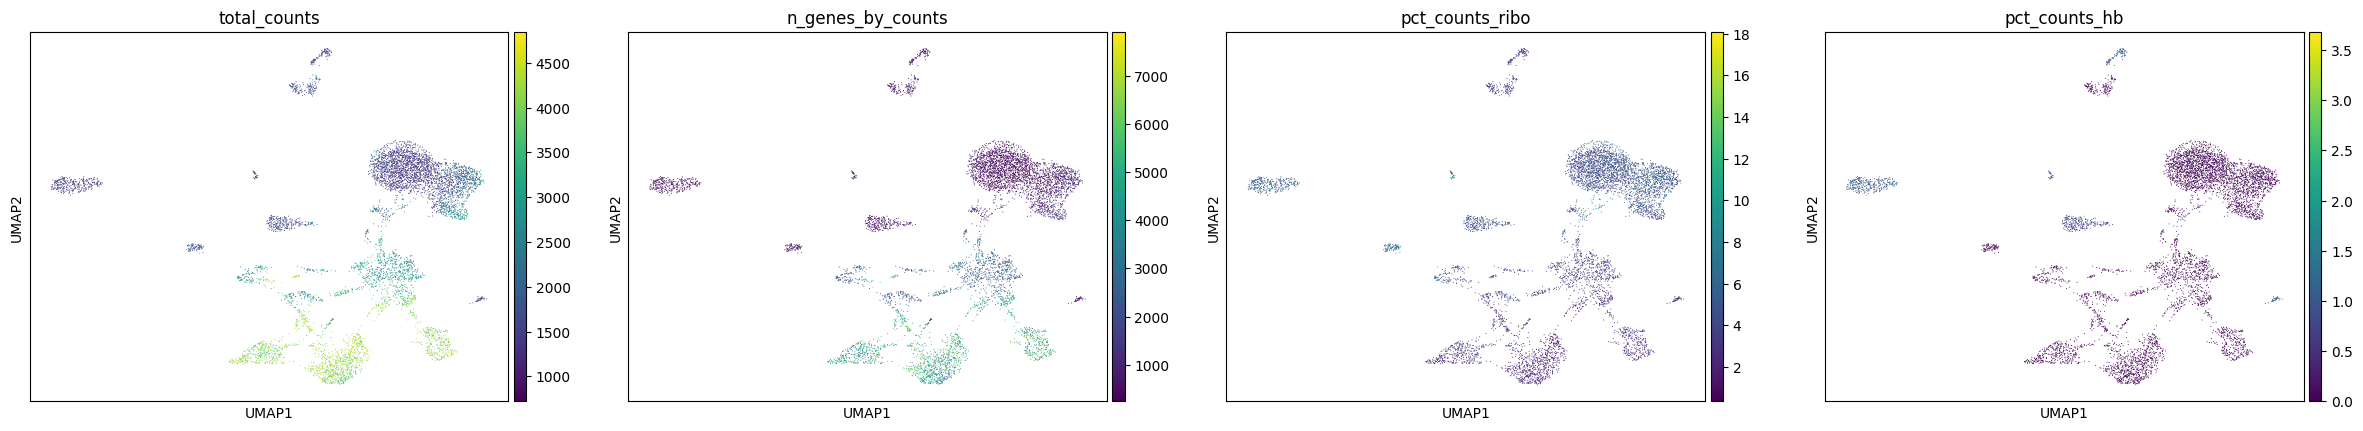

In [34]:
sc.pl.umap(
    adata_hvg,
    color=["total_counts", "n_genes_by_counts", "pct_counts_ribo", "pct_counts_hb"],
    size=2
)

# **3. Clustering de células mediante el algoritmo Leiden**

Se procede a la identificación de agrupaciones celulares mediante técnicas de clustering. En este trabajo se emplea el algoritmo **Leiden**.

A diferencia de otros enfoques, este algoritmo opera directamente sobre el grafo de vecinos previamente construido, lo que permite capturar relaciones locales entre células en el espacio de expresión génica.


In [35]:
!pip install igraph leidenalg
sc.tl.leiden(
    adata_hvg,
    flavor="igraph",
    n_iterations=2
)

print("Clustering Leiden completado")
print("Número de clusters:", adata_hvg.obs["leiden"].nunique())

Clustering Leiden completado
Número de clusters: 21


### **Visualización de los clusters en el espacio UMAP**


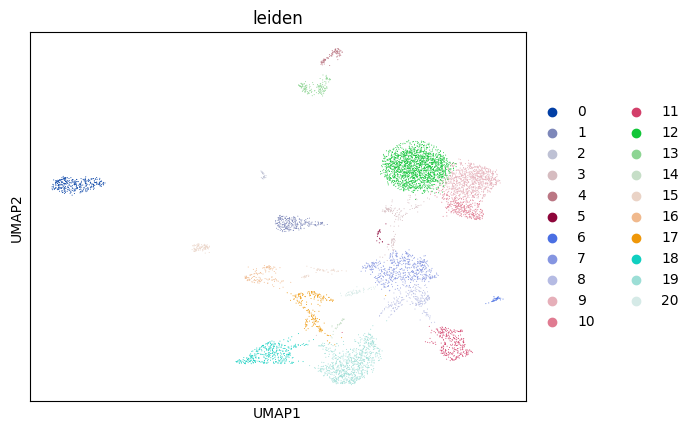

In [36]:
sc.pl.umap(
    adata_hvg,
    color="leiden",
    size=2
)

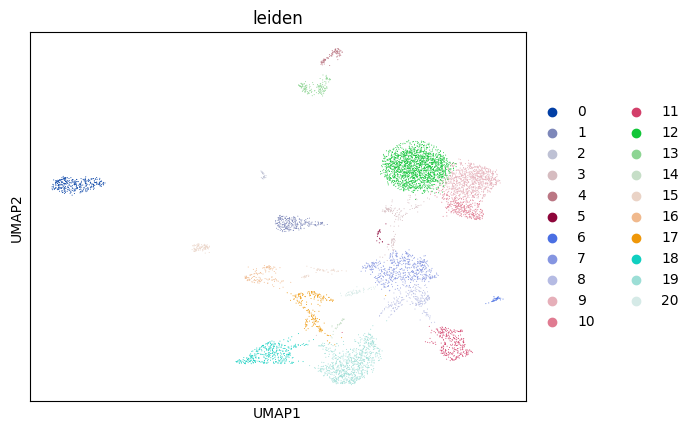

In [37]:
fig = sc.pl.umap(adata_hvg, color="leiden", size=2, show=False)
fig.figure.savefig("umap_leiden.png", dpi=300)

El algoritmo Leiden permitió identificar distintas agrupaciones celulares a partir del grafo de vecindad construido sobre la representación PCA. La proyección de estos clusters sobre el espacio UMAP muestra una organización estructurada del conjunto de datos, en la que las células se agrupan en regiones bien definidas.

Estos clusters representan poblaciones de células con perfiles transcriptómicos similares y constituyen la base para posteriores etapas del experimento, como la anotación de tipos celulares y la evaluación de modelos de clasificación.

## **3.1. Re-evaluación del control de calidad y filtrado**

Tras la obtención de los clusters celulares mediante el algoritmo Leiden, se re-evaluar las métricas de calidad previamente calculadas en el contexto de la estructura global del conjunto de datos.



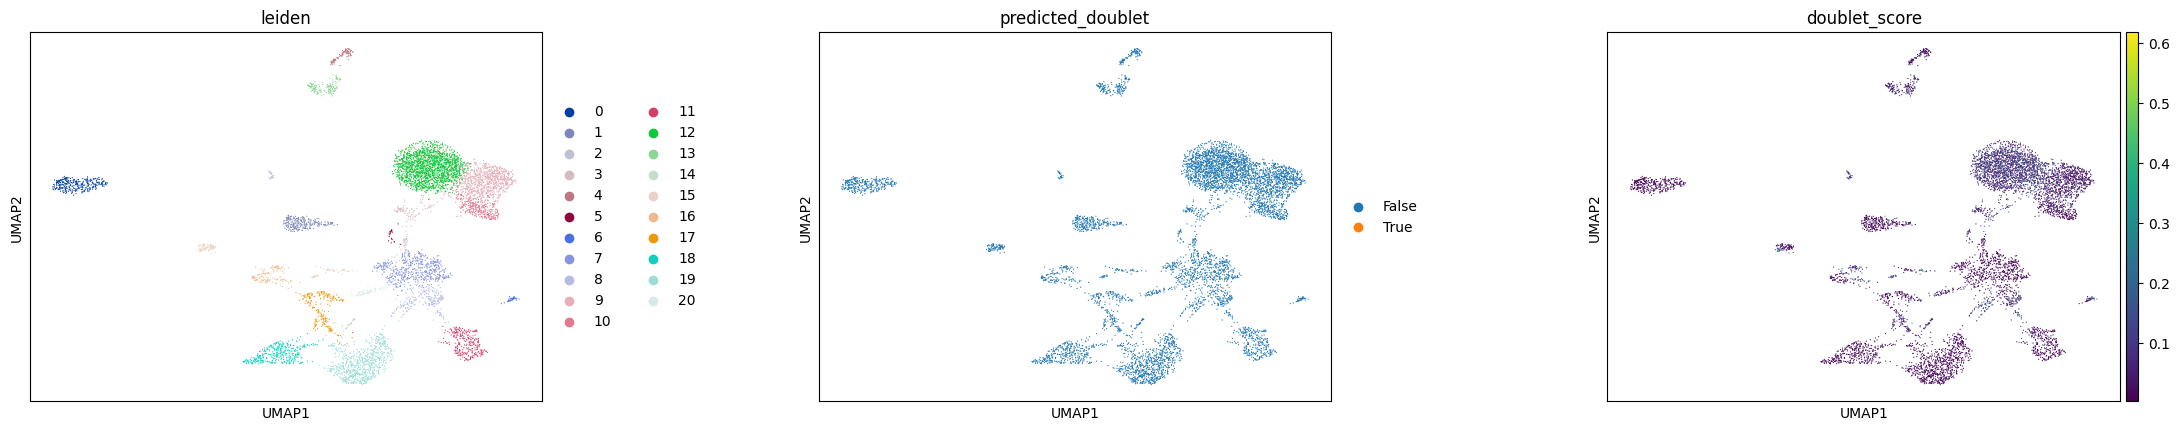

In [38]:
sc.pl.umap(
    adata_hvg,
    color=["leiden", "predicted_doublet", "doublet_score"],
    wspace=0.4,
    size=3
)

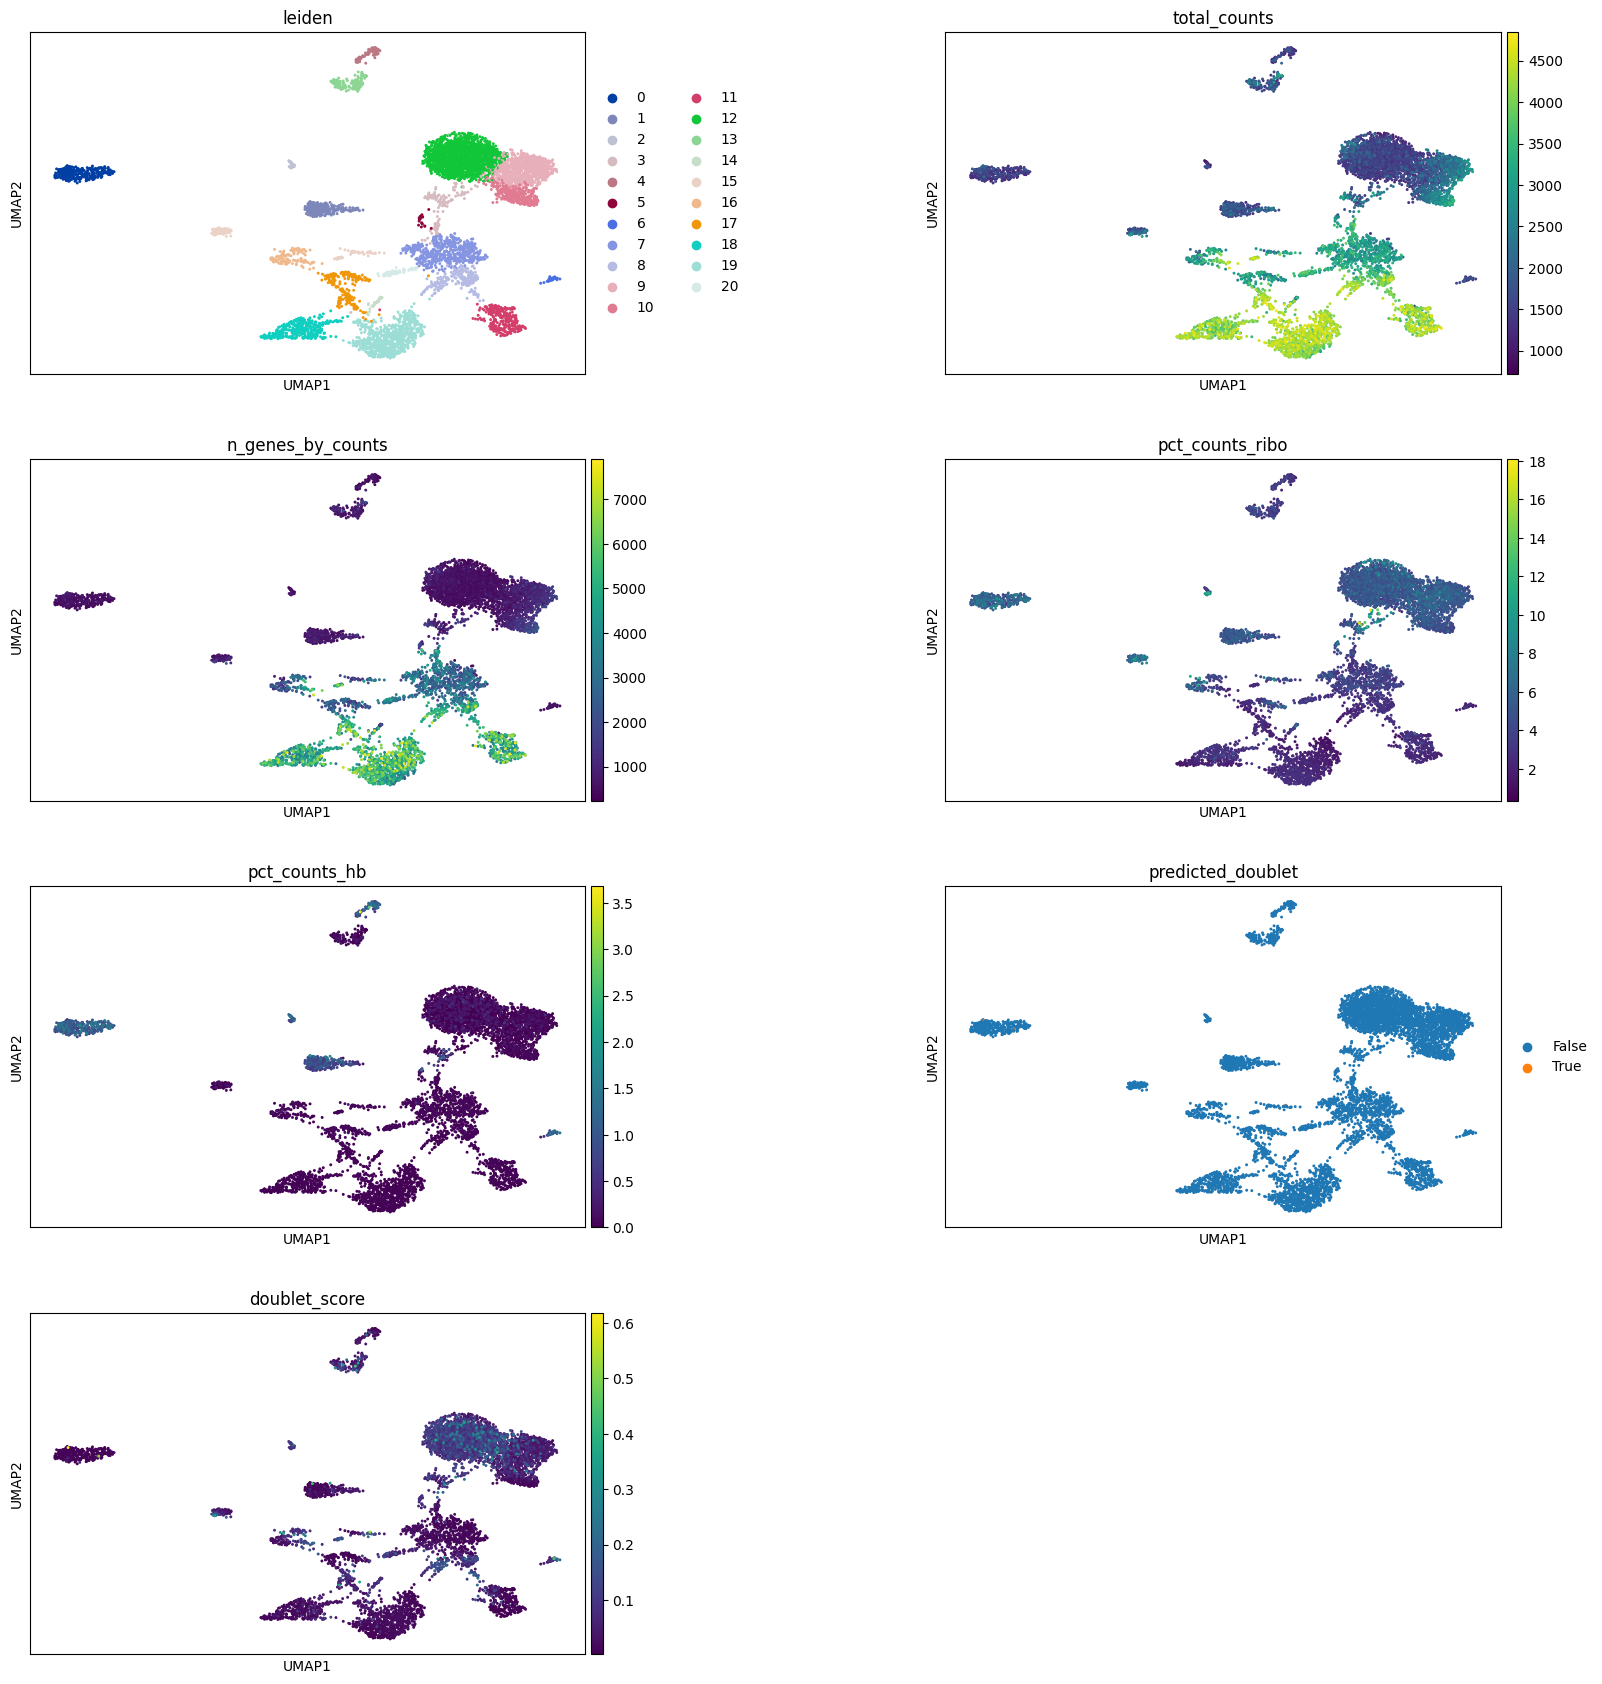

In [39]:
sc.pl.umap(
    adata_hvg,
    color=[
        "leiden",
        "total_counts",
        "n_genes_by_counts",
        "pct_counts_ribo",
        "pct_counts_hb",
        "predicted_doublet",
        "doublet_score"
    ],
    wspace=0.5,
    ncols=2
)

## **3.2. Anotación de tipos celulares**

### **3.2.1. Exploración de la anotación original del dataset**

El conjunto de datos *Mouse from MCA* incorpora una anotación celular previa en la variable `cell_type`, incluida en el benchmark de DANCE.

In [40]:
adata_hvg.obs["cell_type"].value_counts()

,count
cell_type,
6,3970
7,1676
5,436
0,328
4,124
8,72
1,30
3,29
2,26


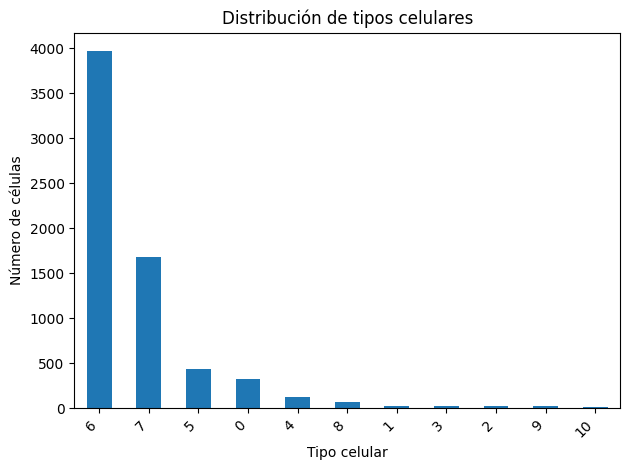

In [41]:
 import matplotlib.pyplot as plt

adata_hvg.obs["cell_type"].value_counts().plot(kind="bar")
plt.title("Distribución de tipos celulares")
plt.xlabel("Tipo celular")
plt.ylabel("Número de células")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

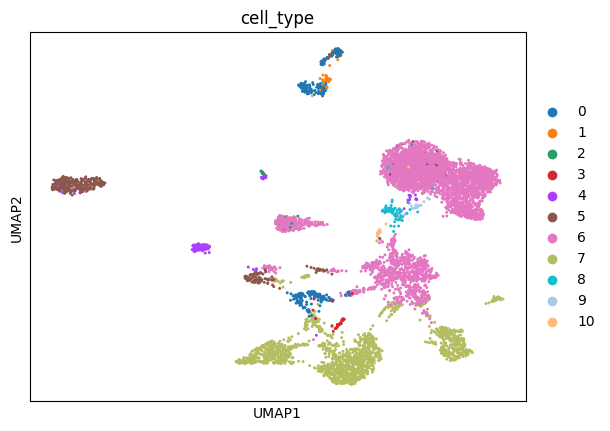

In [42]:
sc.pl.umap(adata_hvg, color="cell_type", legend_loc="right margin")

### **3.2.2. Comparación entre la anotación original y el clustering no supervisado**



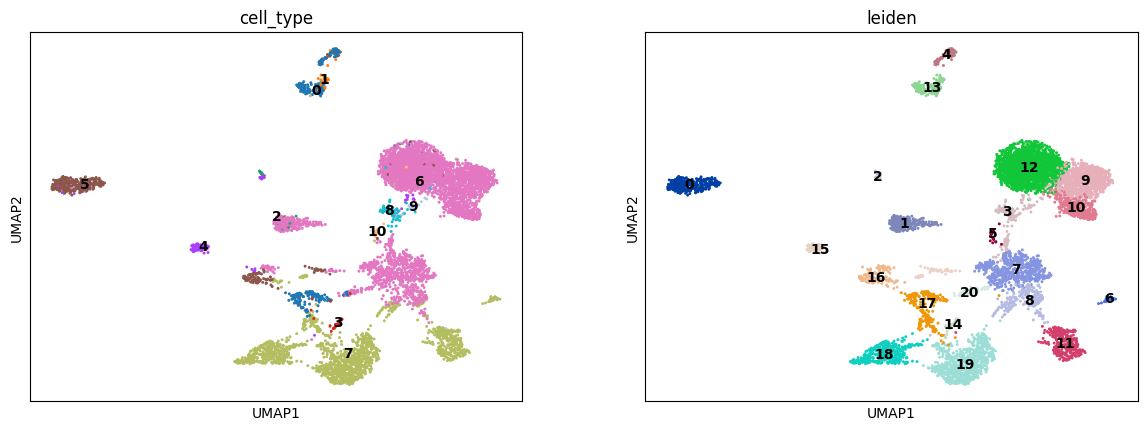

In [43]:
sc.pl.umap(adata_hvg, color=["cell_type", "leiden"], legend_loc="on data")

### **3.3.3. Identificación de genes diferencialmente expresados por cluster**

Se procede a identificar los genes más representativos de cada agrupación mediante un análisis de expresión diferencial.

Este análisis permite detectar genes cuya expresión está significativamente enriquecida en un cluster respecto al resto, facilitando así su interpretación biológica. En este trabajo se emplea el método de Wilcoxon implementado en Scanpy, ampliamente utilizado en el análisis de transcriptómica de célula única para la identificación de genes marcadores.


In [44]:
sc.tl.rank_genes_groups(adata_hvg, groupby="leiden", method="wilcoxon")

/usr/local/lib/python3.11/dist-packages/scanpy/tools/_rank_genes_groups.py:429: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/usr/local/lib/python3.11/dist-packages/scanpy/tools/_rank_genes_groups.py:431: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/usr/local/lib/python3.11/dist-packages/scanpy/tools/_rank_genes_groups.py:434: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result

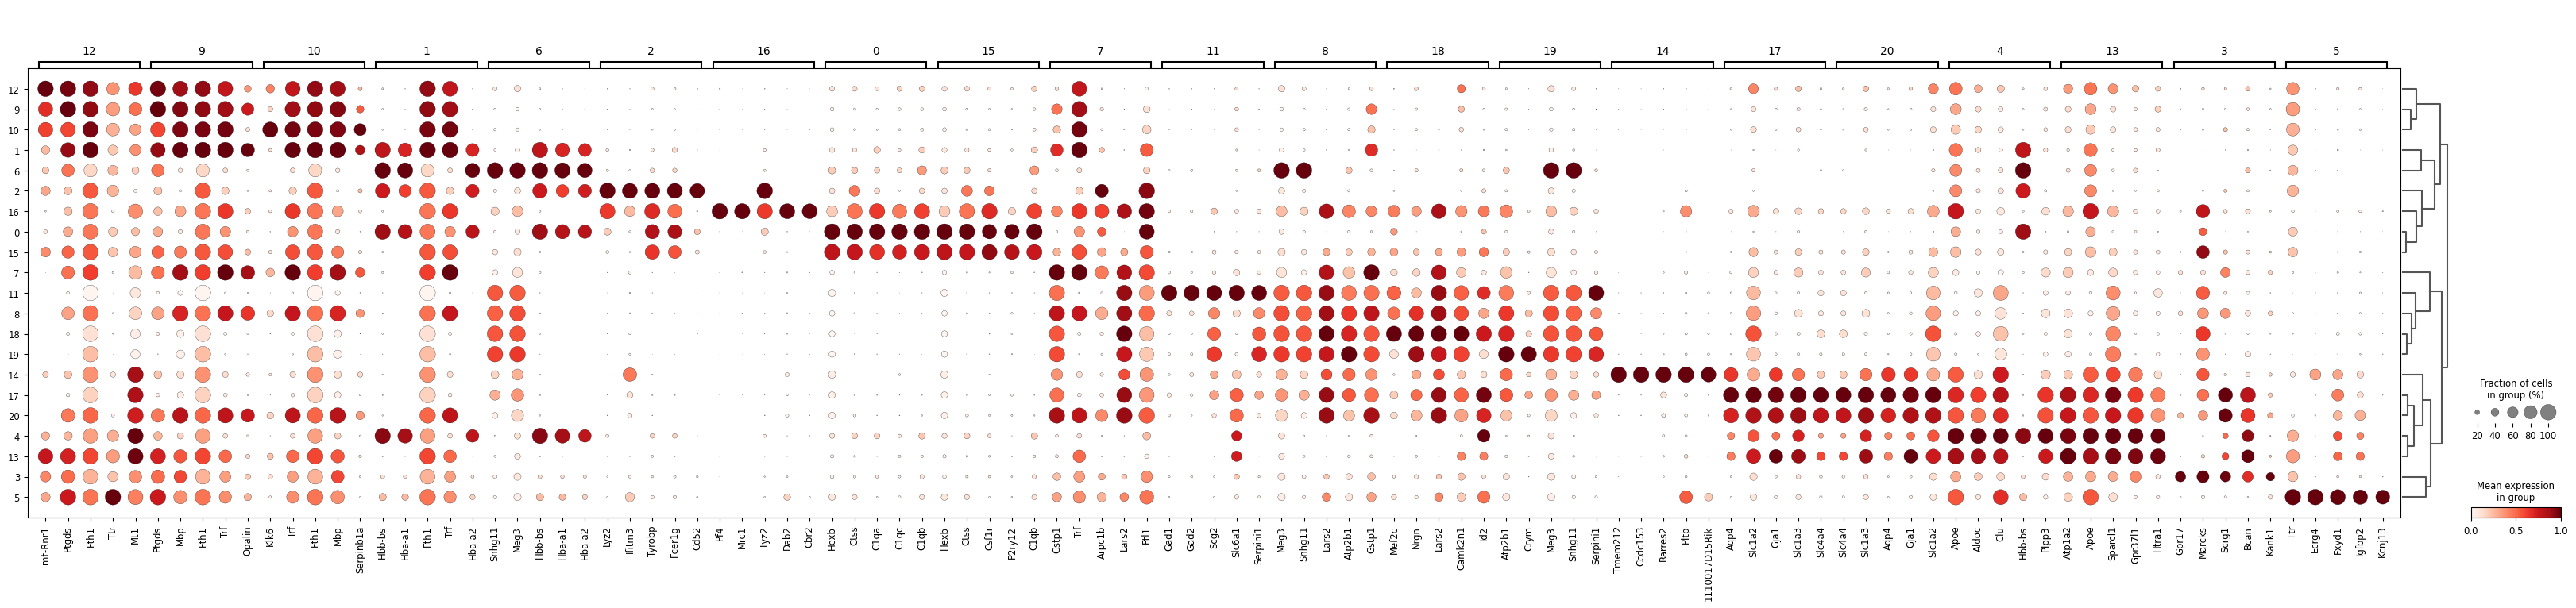

In [45]:
sc.pl.rank_genes_groups_dotplot(
    adata_hvg,
    groupby="leiden",
    n_genes=5,
    standard_scale="var"
)

Para facilitar la interpretación global del clustering, se extraen los genes más representativos de cada cluster en formato tabular. Esta síntesis permite revisar de forma conjunta los posibles genes marcadores asociados a cada agrupación y detectar clusters fácilmente interpretables, así como otros que requieren una revisión más detallada.

In [46]:
clusters = adata_hvg.obs["leiden"].cat.categories
top_n = 10

resumen = {}

for cl in clusters:
    genes = sc.get.rank_genes_groups_df(adata_hvg, group=cl).head(top_n)["names"].tolist()
    resumen[f"cluster_{cl}"] = genes

markers_resumen = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in resumen.items()]))
markers_resumen

,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5,cluster_6,cluster_7,cluster_8,cluster_9,...,cluster_11,cluster_12,cluster_13,cluster_14,cluster_15,cluster_16,cluster_17,cluster_18,cluster_19,cluster_20
0,Hexb,Hbb-bs,Lyz2,Gpr17,Apoe,Ttr,Snhg11,Gstp1,Meg3,Ptgds,...,Gad1,mt-Rnr1,Atp1a2,Tmem212,Hexb,Pf4,Aqp4,Mef2c,Atp2b1,Slc4a4
1,Ctss,Hba-a1,Ifitm3,Marcks,Aldoc,Ecrg4,Meg3,Trf,Snhg11,Mbp,...,Gad2,Ptgds,Apoe,Ccdc153,Ctss,Mrc1,Slc1a2,Nrgn,Crym,Slc1a3
2,C1qa,Fth1,Tyrobp,Scrg1,Clu,Fxyd1,Hbb-bs,Arpc1b,Lars2,Fth1,...,Scg2,Fth1,Sparcl1,Rarres2,Csf1r,Lyz2,Gja1,Lars2,Meg3,Aqp4
3,C1qc,Trf,Fcer1g,Bcan,Hbb-bs,Igfbp2,Hba-a1,Lars2,Atp2b1,Trf,...,Slc6a1,Ttr,Gpr37l1,Pltp,P2ry12,Dab2,Slc1a3,Camk2n1,Snhg11,Gja1
4,C1qb,Hba-a2,Cd52,Kank1,Plpp3,Kcnj13,Hba-a2,Ftl1,Gstp1,Opalin,...,Serpini1,Mt1,Htra1,1110017D15Rik,C1qb,Cbr2,Slc4a4,Id2,Serpini1,Slc1a2
5,Hbb-bs,Mbp,Srgn,Olig2,Sparcl1,Lgals1,Hbb-bt,Opalin,Nrgn,Hcn2,...,Cnr1,Mbp,Aldoc,Fam183b,C1qa,Stab1,Sparcl1,Snhg11,Nrgn,Atp1a2
6,Sparc,Il33,Ftl1,Cacng4,Gpr37l1,Sostdc1,Snhg14,Rps27rt,Mef2c,Ttr,...,Arl4c,Dcaf17,Mt1,Dynlrb2,Cx3cr1,Ms4a7,Clu,Atp2b1,Scg2,Cldn10
7,Ctsd,Opalin,Cyba,Gpr37l1,Atp1a2,Folr1,Cit,Chn2,Arpc1b,Il33,...,Camk2n2,Apoe,Ndrg2,Cfap126,Selplg,F13a1,Scg3,Meg3,Ramp1,Prdx6
8,P2ry12,Ptgds,H2-D1,Nnat,Mt1,Chchd10,Coro6,Ctsl,Ftl1,Gstp-ps,...,Npy,Klk6,Atp1b2,Cd24a,Ctsd,Ctsc,Pla2g7,Pcp4,Cnr1,Plpp3
9,B2m,Hbb-bt,Coro1a,Mfsd2a,Htra1,Rdh5,C1qb,Arsg,Rps27rt,Gna12,...,Synpr,Trf,Clu,Nnat,Laptm5,Ccl7,Atp1a2,Nrsn1,Nnat,Mfge8


# **4. Evaluación de modelos de anotación celular**

## **4.1. Modelos evaluados**

En este experimento se consideran cuatro modelos representativos para la tarea de anotación celular:

- **ACTINN** (*Automated Cell Type Identification using Neural Networks*): modelo basado en redes neuronales profundas, diseñado específicamente para la clasificación automática de tipos celulares a partir de perfiles transcriptómicos.
- **SVM** (*Support Vector Machine*): clasificador supervisado clásico ampliamente utilizado en problemas de clasificación de alta dimensionalidad.
- **Celltypist**: herramienta específica para anotación celular, orientada a la identificación automática de tipos celulares a partir de datos de expresión génica.
- **SingleCellNet**: enfoque basado en Random Forest adaptado a datos de single-cell RNA-seq, que emplea técnicas de normalización y selección de características específicas.
.

In [47]:
from dance.datasets.singlemodality import CellTypeAnnotationDataset
from dance.modules.single_modality.cell_type_annotation.actinn import ACTINN
from dance.modules.single_modality.cell_type_annotation.svm import SVM
from dance.modules.single_modality.cell_type_annotation.celltypist import Celltypist
from dance.modules.single_modality.cell_type_annotation.singlecellnet import SingleCellNet
from dance.modules.single_modality.cell_type_annotation.scdeepsort import ScDeepSort
from dance.utils import set_seed

## **4.2. Preparación de datos**
Como punto de partida para esta fase, se genera una copia del objeto `adata_hvg`, que contiene el conjunto de datos tras el preprocesamiento realizado en el apartado anterior.

A partir de este objeto se extraen:

- la matriz de expresión génica, que actuará como conjunto de variables predictoras,
- y la anotación celular original (`cell_type`), que se utilizará como variable objetivo en la tarea de clasificación supervisada.


In [48]:
print(adata_hvg.obs.columns)

Index(['cell_type', 'n_genes_by_counts', 'total_counts',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes',
       'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes',
       'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo',
       'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes',
       'doublet_score', 'predicted_doublet', 'leiden'],
      dtype='object')


In [49]:
import numpy as np
import pandas as pd
from scipy import sparse

from dance.modules.single_modality.cell_type_annotation.svm import SVM
from dance.utils import set_seed
from sklearn.metrics import (accuracy_score, f1_score, classification_report, confusion_matrix)

import matplotlib.pyplot as plt
import seaborn as sns


# 1. Crear objeto final para modelado
adata_model = adata_hvg.copy()

print("Objeto final para modelado:")
print(adata_model)

Objeto final para modelado:
AnnData object with n_obs × n_vars = 6733 × 2000
    obs: 'cell_type', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'dance_config', 'scrublet', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'predicted_doublet_colors', 'cell_type_colors', 'rank_genes_groups', 'dendrogram_leiden'
    obsm: 'cell_type', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


## **4.3. Entrenamiento de modelos**


### **ACTINN**


In [50]:
# ACTINN CON DATOS PREPROCESADOS EN SCANPY

import numpy as np
from scipy import sparse
import torch

set_seed(0)
# Modelo
model = ACTINN(hidden_dims=[2000], lambd=0.005, device="cpu")

# Split train/test original
adata_hvg.obs["split"] = ["train"] * 4038 + ["test"] * 2695

# Datos preprocesados --------------------
# Opción 1: genes HVG directamente
x = adata_hvg.X
# Opción 2: PCA de Scanpy
#x = adata_hvg.obsm["X_pca"]

if sparse.issparse(x):
    x = x.toarray()
# ---------------------------------


# Etiquetas categóricas
y = adata_hvg.obs["cell_type"].cat.codes.values
n_classes = len(adata_hvg.obs["cell_type"].cat.categories)

# Separar train/test
train_mask = adata_hvg.obs["split"] == "train"
test_mask = adata_hvg.obs["split"] == "test"

x_train = x[train_mask]
x_test = x[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

# Convertir a torch
x_train = torch.tensor(x_train, dtype=torch.float32)
x_test = torch.tensor(x_test, dtype=torch.float32)

# ACTINN necesita etiquetas one-hot
y_train = torch.nn.functional.one_hot(
    torch.tensor(y_train, dtype=torch.long),
    num_classes=n_classes
).float()

y_test = torch.nn.functional.one_hot(
    torch.tensor(y_test, dtype=torch.long),
    num_classes=n_classes
).float()


# Entrenar
model.fit(x_train, y_train, seed=0, lr=0.0001, num_epochs=50, batch_size=128, print_cost=True)

# Evaluar
y_pred_actinn_scanpy = model.predict(x_test)
acc_actinn_scanpy = model.score(x_test, y_test)
print(f"ACTINN ACC Scanpy: {acc_actinn_scanpy:.4f}")

# Guardado para evaluación
model_actinn_scanpy = model
x_test_actinn_scanpy = x_test
y_test_actinn_scanpy = y_test
y_pred_actinn_scanpy = y_pred_actinn_scanpy

[INFO][2026-05-19 17:19:58,794][dance][set_seed] Setting global random seed to 0


Epoch:    0 Loss: 5.5205
Epoch:   10 Loss: 1.5494
Epoch:   20 Loss: 0.5669
Epoch:   30 Loss: 0.2606
Epoch:   40 Loss: 0.1546
ACTINN ACC Scanpy: 0.8063


### **SVM**


In [51]:
# SVM CON DATOS PREPROCESADOS EN SCANPY

from argparse import Namespace
import numpy as np
from scipy import sparse
from sklearn.metrics import accuracy_score
from dance.modules.single_modality.cell_type_annotation.svm import SVM
from dance.utils import set_seed

#configuración
seed = 42
set_seed(seed)

args = Namespace(
    dense_dim=400,
    gpu=-1,
    log_level="INFO",
    seed=seed,
    num_runs=1
)

# Modelo
model = SVM(args, random_state=seed)


# Split train/test original
adata_hvg.obs["split"] = ["train"] * 4038 + ["test"] * 2695


# extraer matrix preprocesada ------------------
# x = adata_hvg.obsm["X_pca"]   # usar PCA

# O usar HVGs:
x = adata_hvg.X

if sparse.issparse(x):
    x = x.toarray()
# ------------------


# Etiquetas categóricas guardadas en obs
y = adata_hvg.obs["cell_type"].cat.codes.values


# Separar train/test
train_mask = adata_hvg.obs["split"] == "train"
test_mask = adata_hvg.obs["split"] == "test"

x_train = x[train_mask]
x_test = x[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

print("Train:", x_train.shape, y_train.shape)
print("Test:", x_test.shape, y_test.shape)


# Entrenar
model.fit(x_train, y_train)

# Evaluar
y_pred_svm_scanpy = model.predict(x_test) # cambiar a one-hot

acc_svm_scanpy = np.mean(y_pred_svm_scanpy == y_test)

print(f"SVM ACC Scanpy: {acc_svm_scanpy:.4f}")

# Guardado para evaluación
model_svm_scanpy = model
x_test_svm_scanpy = x_test
y_test_svm_scanpy = y_test
y_pred_svm_scanpy = y_pred_svm_scanpy


[INFO][2026-05-19 17:22:26,660][dance][set_seed] Setting global random seed to 42


Train: (4038, 2000) (4038,)
Test: (2695, 2000) (2695,)
SVM ACC Scanpy: 0.7829


In [52]:
print(acc_svm_scanpy)

0.7829313543599258


### **Celltypist**


In [53]:
# CELLTYPIST CON DATOS PREPROCESADOS EN SCANPY

import numpy as np
from scipy import sparse

from dance.utils import set_seed
from dance.modules.single_modality.cell_type_annotation.celltypist import Celltypist

# Reproducibilidad
set_seed(42)

# Modelo
model = Celltypist(majority_voting=False) #Indicar False, no True

# Split train/test original
adata_hvg.obs["split"] = ["train"] * 4038 + ["test"] * 2695

# Datos preprocesados - usar HVG, NO PCA -------------------------
x = adata_hvg.X
# Usar PCA:
# x = adata_hvg.obsm["X_pca"]
if sparse.issparse(x):
    x = x.toarray()
# --------------------------------------------------------------


# Etiquetas categóricas
y = adata_hvg.obs["cell_type"].cat.codes.values

# Separar train/test
train_mask = adata_hvg.obs["split"] == "train"
test_mask = adata_hvg.obs["split"] == "test"

x_train = x[train_mask]
x_test = x[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

print("Train:", x_train.shape, y_train.shape)
print("Test:", x_test.shape, y_test.shape)

# Entrenamiento
model.fit(
    x_train,
    y_train,
    n_jobs=10,
    max_iter=200,
    use_SGD=True
)

# Evaluación
y_pred_celltypist_scanpy = model.predict(x_test)

acc_celltypist_scanpy = np.mean(y_pred_celltypist_scanpy == y_test)

print(f"Celltypist ACC Scanpy: {acc_celltypist_scanpy:.4f}")

# Guardado para evaluación
model_celltypist_scanpy = model
x_test_celltypist_scanpy = x_test
y_test_celltypist_scanpy = y_test
y_pred_celltypist_scanpy = y_pred_celltypist_scanpy

[INFO][2026-05-19 17:24:24,724][dance][set_seed] Setting global random seed to 42
[INFO][2026-05-19 17:24:24,757][dance][fit] Preparing data before training
[INFO][2026-05-19 17:24:24,760][dance][fit] Scaling input data


Train: (4038, 2000) (4038,)
Test: (2695, 2000) (2695,)


[INFO][2026-05-19 17:24:24,924][dance][SGDClassifier_celltypist] Training data using SGD logistic regression
[INFO][2026-05-19 17:24:24,926][dance][SGDClassifier_celltypist] SGDlassifier training start...
[INFO][2026-05-19 17:24:27,311][dance][fit] Model training done
[INFO][2026-05-19 17:24:27,317][dance][__init__] Input data has 2,695 cells and 2,000 genes
[INFO][2026-05-19 17:24:27,319][dance][celltype] Matching reference genes in the model
[INFO][2026-05-19 17:24:27,417][dance][celltype] 2,000 features used for prediction
[INFO][2026-05-19 17:24:27,815][dance][celltype] Scaling input data
[INFO][2026-05-19 17:24:27,886][dance][celltype] Predicting labels
[INFO][2026-05-19 17:24:27,925][dance][celltype] Prediction done


Celltypist ACC Scanpy: 0.3525


### **SingleCellNet**

In [54]:
# SINGLECELLNET CON DATOS PREPROCESADOS EN SCANPY


import numpy as np
from scipy import sparse
from dance.utils import set_seed
from dance.modules.single_modality.cell_type_annotation.singlecellnet import SingleCellNet

# Reproducibilidad
set_seed(10)

# Modelo
model = SingleCellNet(num_trees=1000)

# Split train/test original de DANCE
adata_hvg.obs["split"] = ["train"] * 4038 + ["test"] * 2695

# Datos preprocesados con Scanpy ------------------------
# SingleCellNet trabaja con expresión génica.
# Por tanto, se usa la matriz de genes altamente variables,
# no la representación PCA.
x = adata_hvg.X
# PCA:
#x = adata_hvg.obsm["X_pca"]
#if sparse.issparse(x):
    #x = x.toarray()
# -----------------------------------------

# Etiquetas
y = adata_hvg.obs["cell_type"].cat.codes.values

# Separar train/test
train_mask = adata_hvg.obs["split"] == "train"
test_mask = adata_hvg.obs["split"] == "test"

x_train = x[train_mask]
x_test = x[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

print("Train:", x_train.shape, y_train.shape)
print("Test:", x_test.shape, y_test.shape)

# Entrenar
model.fit(x_train, y_train, stratify=True, num_rand=100, random_state=10)

# Evaluar
y_pred_scn_scanpy = model.predict(x_test)
acc_scn_scanpy = np.mean(y_pred_scn_scanpy == y_test)
print(f"SingleCellNet ACC Scanpy: {acc_scn_scanpy:.4f}")

# Guardado para evaluación
model_scn_scanpy = model
x_test_scn_scanpy = x_test
y_test_scn_scanpy = y_test
y_pred_scn_scanpy = y_pred_scn_scanpy
acc_scn_scanpy = acc_scn_scanpy

[INFO][2026-05-19 17:24:27,954][dance][set_seed] Setting global random seed to 10


Train: (4038, 2000) (4038,)
Test: (2695, 2000) (2695,)
SingleCellNet ACC Scanpy: 0.3532


## **4.4. Tabla de resultados**
En particular, se consideran las siguientes métricas:

- **Accuracy**: proporción de predicciones correctas sobre el total de muestras.
- **Balanced Accuracy**: promedio del recall obtenido en cada clase, proporcionando una evaluación más robusta en escenarios con desbalanceo entre clases.
- **F1-score macro**: promedio no ponderado del F1-score calculado independientemente para cada clase, otorgando la misma relevancia a todas las categorías.
- **ARI (Adjusted Rand Index)**: mide la concordancia entre las etiquetas reales y las predichas, corrigiendo el efecto del azar.




In [55]:
import pandas as pd

# Crear tabla de resultados
tabla_resultados = pd.DataFrame({
    "Modelo": [
        "SVM",
        "ACTINN",
        "SingleCellNet",
        "Celltypist (DANCE)"
    ],
    "Configuración": [
        "Scanpy",
        "Scanpy (HVG)",
        "Scanpy (HVG)",
        "Scanpy"
    ],
    "Accuracy": [
        acc_svm_scanpy,
        acc_actinn_scanpy,
        acc_scn_scanpy,
        acc_celltypist_scanpy
    ]
})

# Redondear
tabla_resultados["Accuracy"] = tabla_resultados["Accuracy"].round(4)

# Mostrar
print(tabla_resultados)

               Modelo Configuración  Accuracy
0                 SVM        Scanpy    0.7829
1              ACTINN  Scanpy (HVG)    0.8063
2       SingleCellNet  Scanpy (HVG)    0.3532
3  Celltypist (DANCE)        Scanpy    0.3525


In [56]:
# Tabla final de Accuracy de todos los modelos
tabla_accuracy_final = pd.DataFrame([
    {
        "Modelo": "SVM",
        "Preprocesamiento": "Scanpy",
        "Accuracy": acc_svm_scanpy
    },
    {
        "Modelo": "Celltypist",
        "Preprocesamiento": "Scanpy",
        "Accuracy": acc_celltypist_scanpy
    },
    {
        "Modelo": "SingleCellNet",
        "Preprocesamiento": "Scanpy",
        "Accuracy": acc_scn_scanpy
    },
    {
        "Modelo": "ACTINN",
        "Preprocesamiento": "Scanpy",
        "Accuracy": acc_actinn_scanpy
    }
])

tabla_accuracy_final = tabla_accuracy_final.sort_values(
    by="Accuracy",
    ascending=False
).round(4)

display(tabla_accuracy_final)

,Modelo,Preprocesamiento,Accuracy
3,ACTINN,Scanpy,0.8063
0,SVM,Scanpy,0.7829
2,SingleCellNet,Scanpy,0.3532
1,Celltypist,Scanpy,0.3525


In [57]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

# ============================================================
# CALCULAR MÉTRICAS
# ============================================================

def calcular_metricas(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "ARI": adjusted_rand_score(y_true, y_pred),
        "NMI": normalized_mutual_info_score(y_true, y_pred)
    }

# ============================================================
# RESULTADOS DE CADA MODELO
# ============================================================

res_svm = calcular_metricas(y_test_svm_scanpy, y_pred_svm_scanpy)
res_actinn = calcular_metricas(y_test_actinn_scanpy.argmax(1).cpu().numpy(), y_pred_actinn_scanpy)
res_scn = calcular_metricas(y_test_scn_scanpy, y_pred_scn_scanpy)
res_celltypist = calcular_metricas(y_test_celltypist_scanpy, y_pred_celltypist_scanpy)

# ============================================================
# TABLA FINAL
# ============================================================

tabla_resultados = pd.DataFrame([
    {"Modelo": "SVM", **res_svm},
    {"Modelo": "ACTINN", **res_actinn},
    {"Modelo": "SingleCellNet", **res_scn},
    {"Modelo": "Celltypist", **res_celltypist}
])

# Redondear
tabla_resultados = tabla_resultados.round(4)

# Ordenar por F1 (más interesante que accuracy)
tabla_resultados = tabla_resultados.sort_values(by="F1_macro", ascending=False)

# Mostrar
tabla_resultados

,Modelo,Accuracy,Precision_macro,Recall_macro,F1_macro,ARI,NMI
0,SVM,0.7829,0.4564,0.3904,0.3756,0.5129,0.5545
1,ACTINN,0.8063,0.3765,0.3915,0.3647,0.6090,0.5502
3,Celltypist,0.3525,0.3917,0.3195,0.2842,0.2254,0.3913
2,SingleCellNet,0.3532,0.5443,0.2738,0.2505,0.0833,0.3357


## **4.5. Visualización**


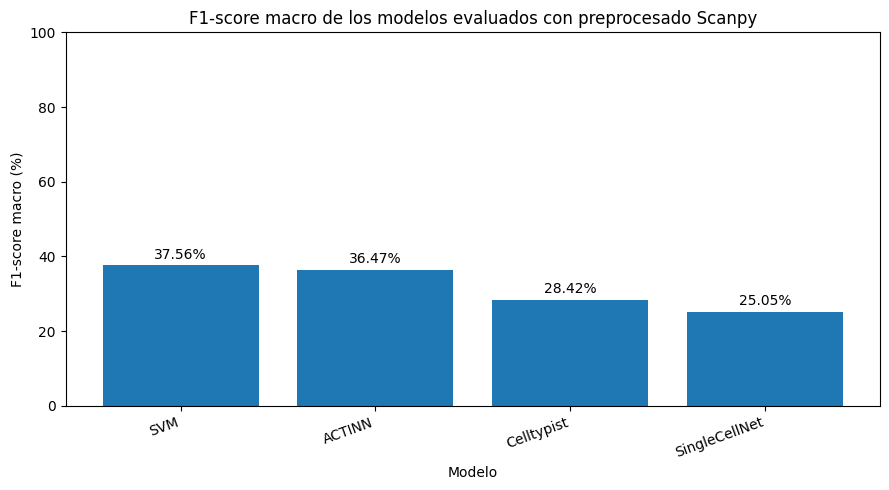

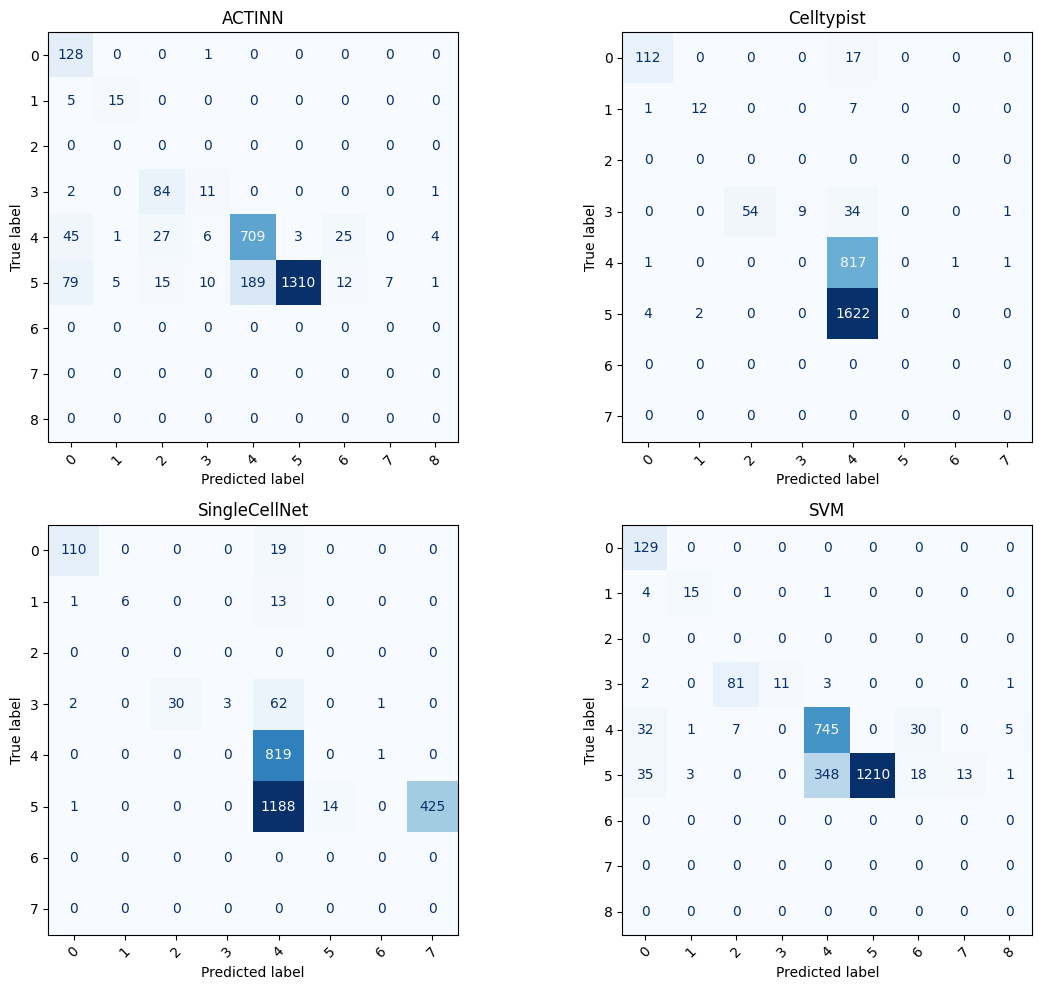

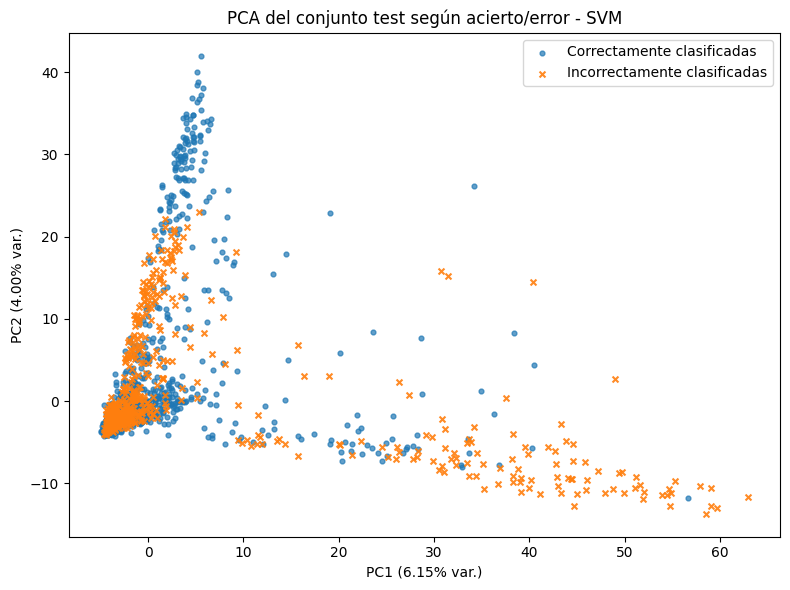

PCA generado para el modelo SVM. Varianza explicada acumulada por PC1 y PC2: 10.15%.


In [59]:
# ============================================================
# VISUALIZACIÓN DE RESULTADOS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy import sparse
import torch




# ============================================================
# FIGURA 2: F1 MACRO
# ============================================================

plt.figure(figsize=(9, 5))

bars = plt.bar(
    df_metricas["modelo"],
    df_metricas["f1_macro"] * 100
)

plt.title("F1-score macro de los modelos evaluados con preprocesado Scanpy")
plt.xlabel("Modelo")
plt.ylabel("F1-score macro (%)")
plt.ylim(0, 100)

for bar, value in zip(bars, df_metricas["f1_macro"] * 100):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(output_dir / "f1_macro_modelos_scanpy.png", dpi=300)
plt.show()



# ============================================================
# MATRICES DE CONFUSIÓN COMBINADAS 2x2
# ============================================================

modelos_orden = ["ACTINN", "Celltypist", "SingleCellNet", "SVM"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, modelo in enumerate(modelos_orden):

    y_true, y_pred = predicciones_modelos[modelo]

    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(
        ax=axes[i],
        cmap="Blues",
        colorbar=False,
        xticks_rotation=45
    )

    axes[i].set_title(modelo)

plt.tight_layout()
plt.savefig(output_dir / "matrices_confusion_combined_scanpy.png", dpi=300)
plt.show()



# ============================================================
# PCA DEL CONJUNTO TEST SEGÚN ACIERTO / ERROR
# ============================================================

mejor_modelo_nombre = df_metricas.iloc[0]["modelo"]

x_test_mejor = modelos_evaluacion[mejor_modelo_nombre]
y_true_mejor, y_pred_mejor = predicciones_modelos[mejor_modelo_nombre]

x_test_np = to_numpy(x_test_mejor)

x_test_scaled = StandardScaler().fit_transform(x_test_np)

pca = PCA(n_components=2, random_state=42)
x_pca = pca.fit_transform(x_test_scaled)

aciertos = y_true_mejor == y_pred_mejor

plt.figure(figsize=(8, 6))

plt.scatter(
    x_pca[aciertos, 0],
    x_pca[aciertos, 1],
    s=12,
    alpha=0.7,
    label="Correctamente clasificadas"
)

plt.scatter(
    x_pca[~aciertos, 0],
    x_pca[~aciertos, 1],
    s=18,
    alpha=0.9,
    label="Incorrectamente clasificadas",
    marker="x"
)

plt.title(f"PCA del conjunto test según acierto/error - {mejor_modelo_nombre}")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% var.)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% var.)")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / f"pca_acierto_error_{mejor_modelo_nombre}_scanpy.png", dpi=300)
plt.show()

print(
    f"PCA generado para el modelo {mejor_modelo_nombre}. "
    f"Varianza explicada acumulada por PC1 y PC2: "
    f"{pca.explained_variance_ratio_.sum()*100:.2f}%."
)


